In [ ]:
# importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [ ]:
# Load the dataset
df = pd.read_csv('Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
# Check for missing values and duplications

missing_values = df.isna().sum().sum()
duplications = df.duplicated().sum()
print("Missing values:\n", missing_values)
print("Duplications:", duplications)
print(f"Unique crops: {df['label'].unique()}")

Missing values:
 0
Duplications: 0
Unique crops: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [144]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
# Feature engineering

df['Total_NPK'] = df['N'] + df['P'] + df['K']
df['N_P_ratio'] = df['N'] / (df['P'] + 1e-5)
df['N_K_ratio'] = df['N'] / (df['K'] + 1e-5)
df['P_K_ratio'] = df['P'] / (df['K'] + 1e-5)
df['THI'] = 0.8 * df['temperature'] + (df['humidity'] / 100) * (df['temperature'] - 14.4) + 46.4
df['Rain_per_Humidity'] = df['rainfall'] / (df['humidity'] + 1e-5)
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,Total_NPK,N_P_ratio,N_K_ratio,P_K_ratio,THI,Rain_per_Humidity
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,2.142857,2.093023,0.976744,68.417363,2.474740
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,1.465517,2.073170,1.414634,69.736298,2.821919
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,1.090909,1.363636,1.250000,71.886824,3.206533
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,2.114285,1.850000,0.875000,77.284902,3.029802
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,1.857142,1.857142,1.000000,67.180242,3.219383


In [147]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label',
       'Total_NPK', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'THI',
       'Rain_per_Humidity'],
      dtype='object')

In [148]:
sns.set_style('whitegrid')

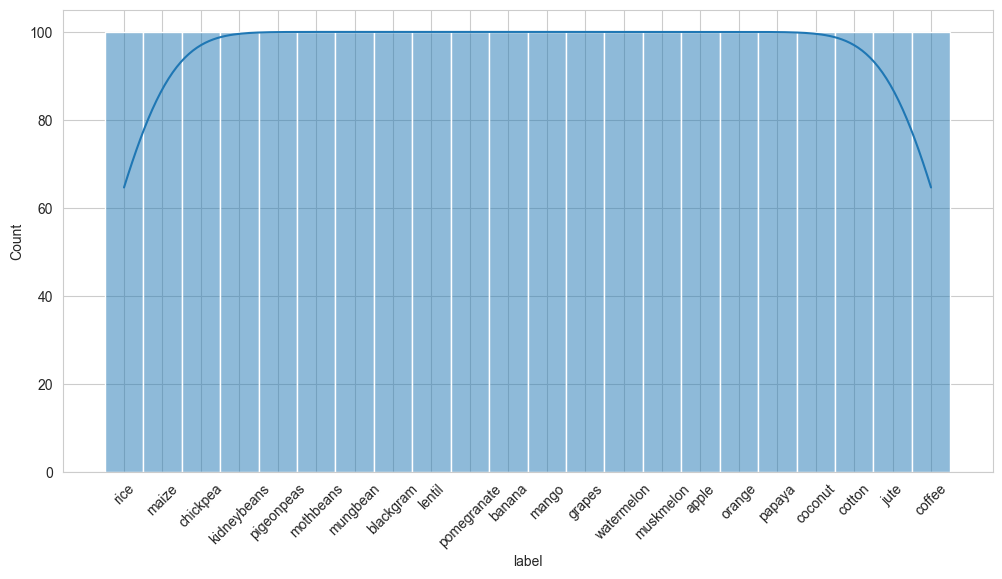

In [ ]:
# Distribution of crops

plt.figure(figsize=(12, 6))
sns.histplot(df, x="label", kde=True)
plt.xticks(rotation=45)
plt.show()

Text(0.5, 1.0, 'K Distribution')

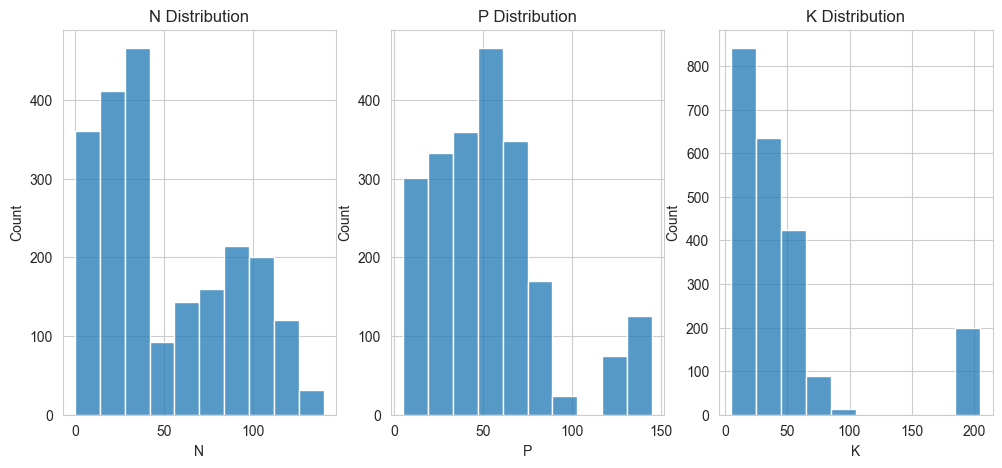

In [ ]:
# Distribution of N, P, K

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
sns.histplot(data=df, x="N", bins=10, ax=axes[0])
axes[0].set_title("Nitrogen Distribution")

sns.histplot(data=df, x="P", bins=10, ax=axes[1])
axes[1].set_title("Phosphorus Distribution")

sns.histplot(data=df, x="K", bins=10, ax=axes[2])
axes[2].set_title("Potassium Distribution")

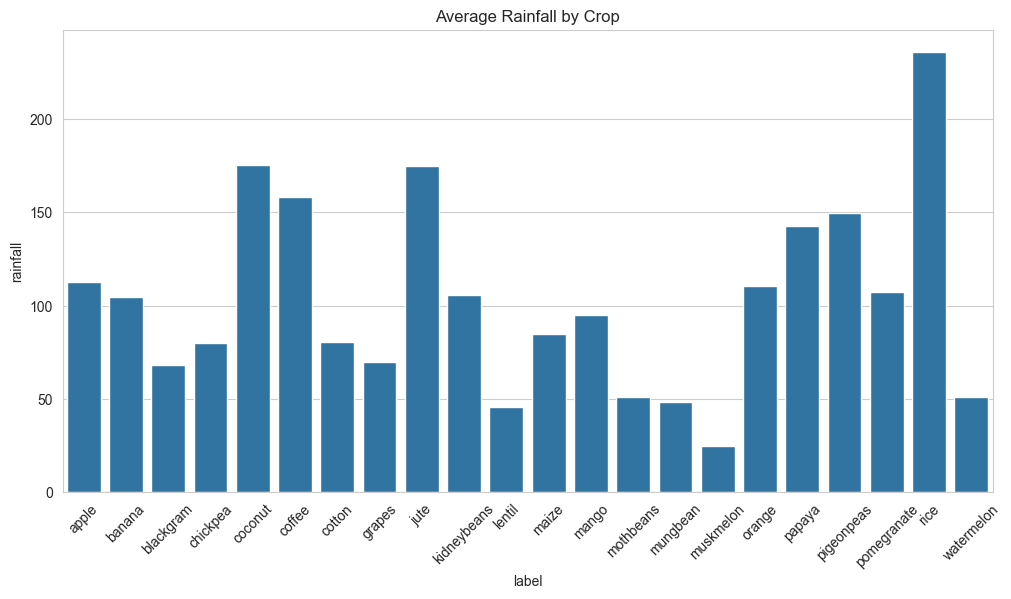

In [ ]:
# Average rainfall by crop

rainfall = df.groupby('label')['rainfall'].mean()
rainfall_df = rainfall.reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=rainfall_df, x="label", y="rainfall")
plt.title("Average Rainfall by Crop")
plt.xticks(rotation=45)
plt.show()

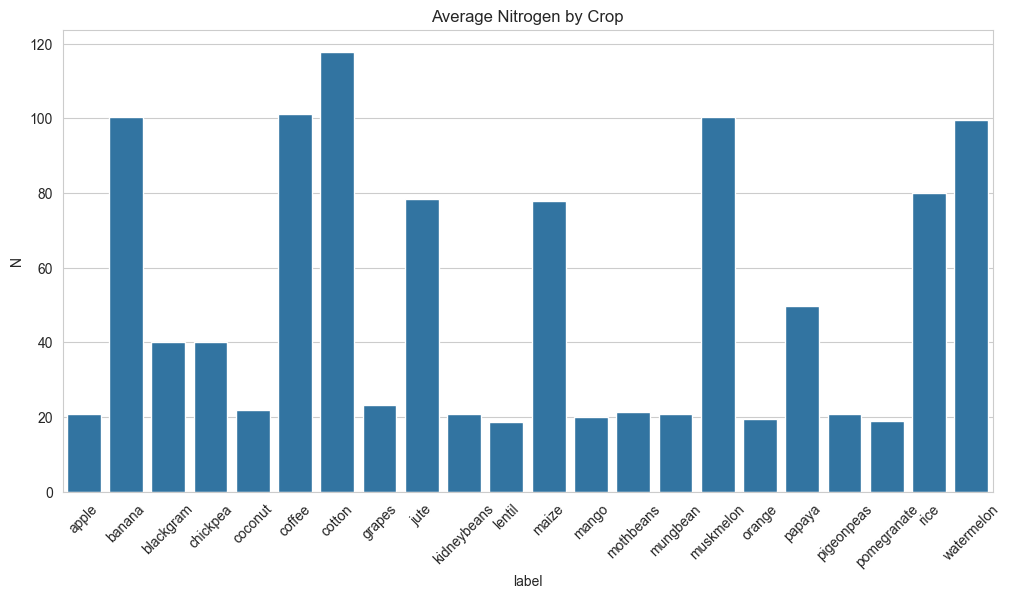

In [ ]:
# Average nitrogen by crop

n = df.groupby('label')['N'].mean()
n_df = n.reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=n_df, x="label", y="N")
plt.title("Average Nitrogen by Crop")
plt.xticks(rotation=45)
plt.show()

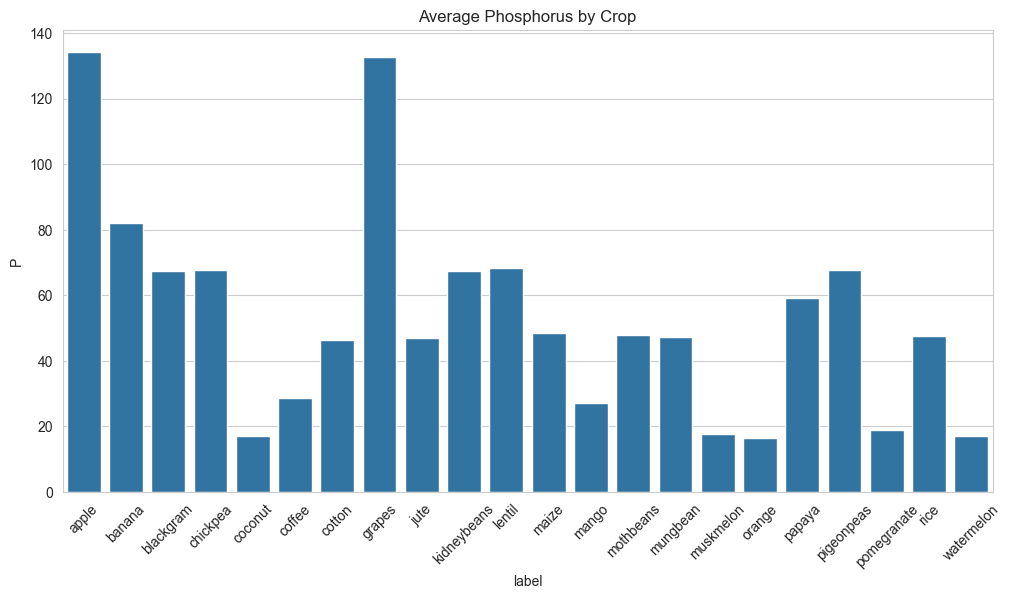

In [ ]:
# Average phosphorus by crop

p = df.groupby('label')['P'].mean()
p_df = p.reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=p_df, x="label", y="P")
plt.title("Average Phosphorus by Crop")
plt.xticks(rotation=45)
plt.show()

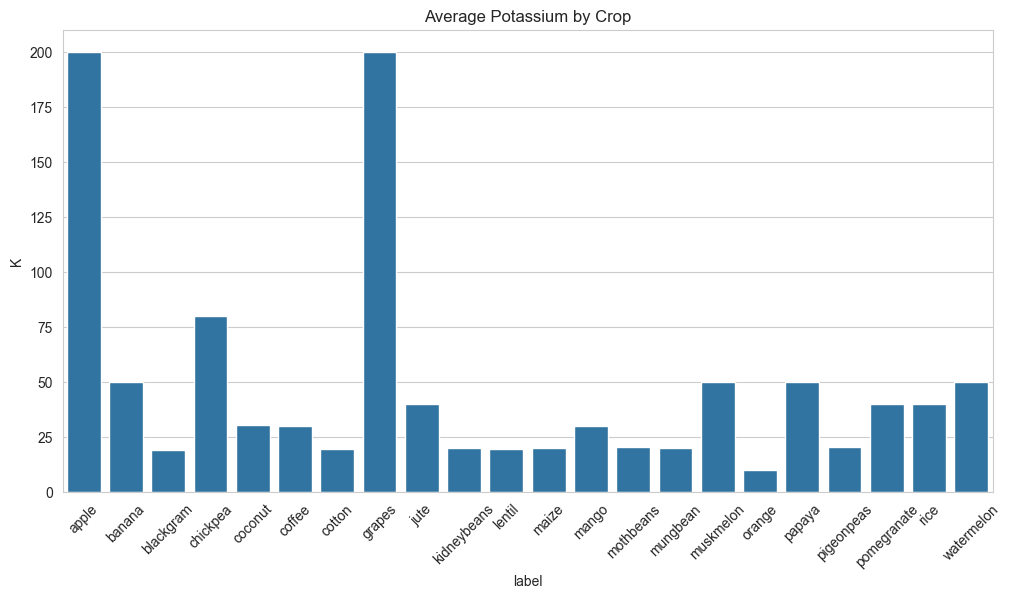

In [ ]:
# Average potassium by crop

k = df.groupby('label')['K'].mean()
k_df = k.reset_index()


plt.figure(figsize=(12, 6))
sns.barplot(data=k_df, x="label", y="K")
plt.title("Average Potassium by Crop")
plt.xticks(rotation=45)
plt.show()

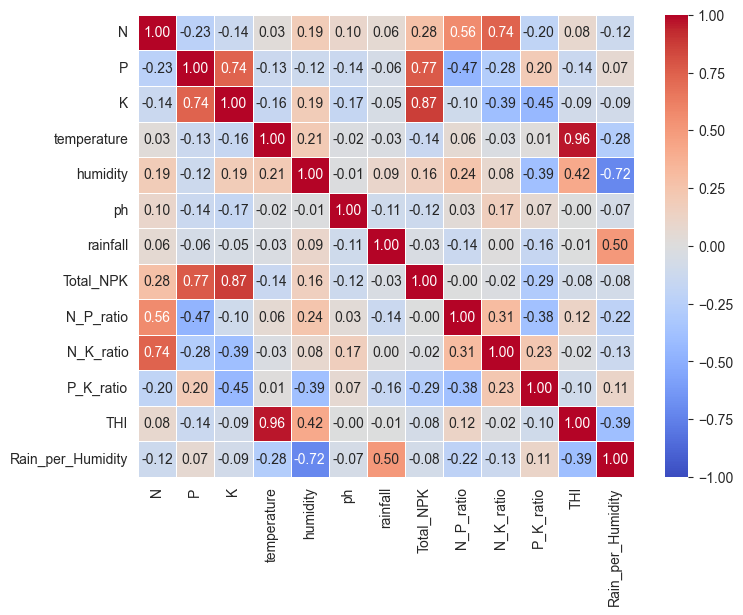

In [ ]:
# Correlation heatmap

corr_matrix = df.drop(columns=["label"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,      
    cmap="coolwarm",  
    fmt=".2f",       
    linewidths=0.5,   
    vmin=-1, vmax=1   
)
plt.show()

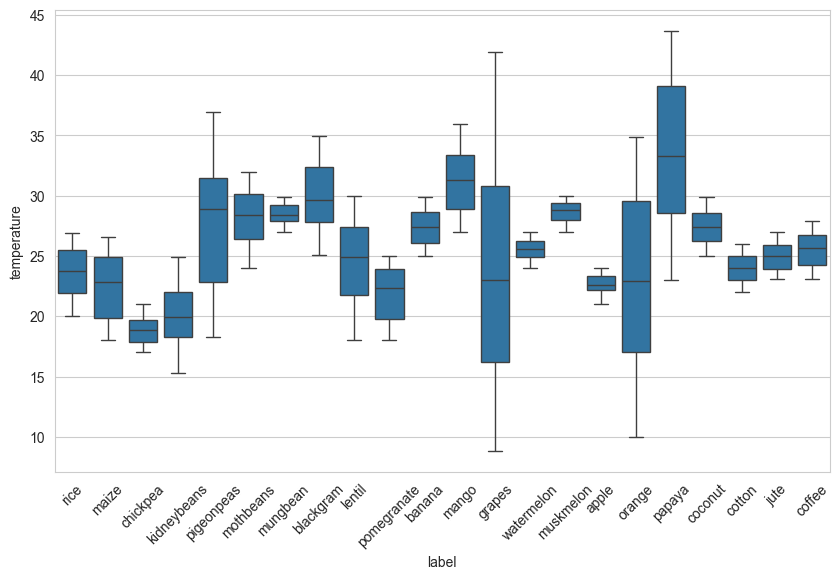

In [ ]:
# Boxplot of temperature by crop

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="label", y="temperature")
plt.xticks(rotation=45)
plt.show()

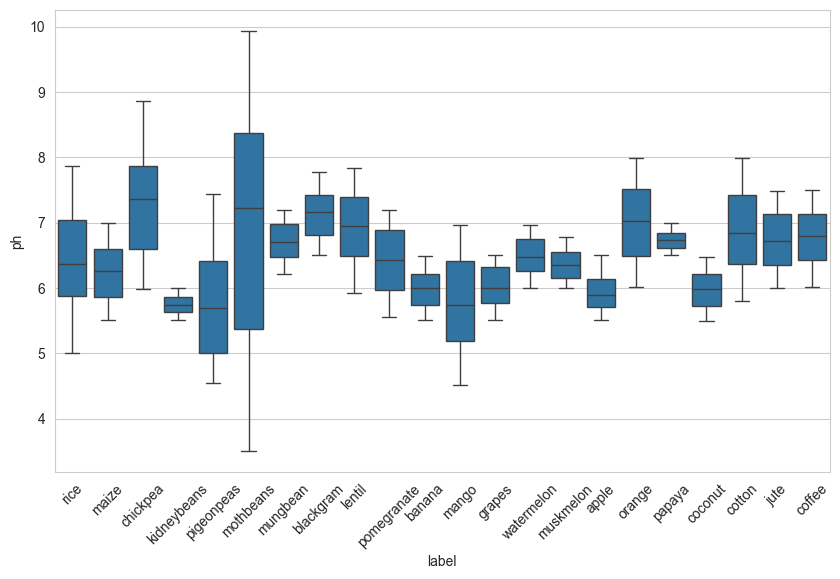

In [ ]:
# Boxplot of humidity by crop

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="label", y="ph")
plt.xticks(rotation=45)
plt.show()

In [158]:
# sns.pairplot(df, hue="label", diag_kind="kde")

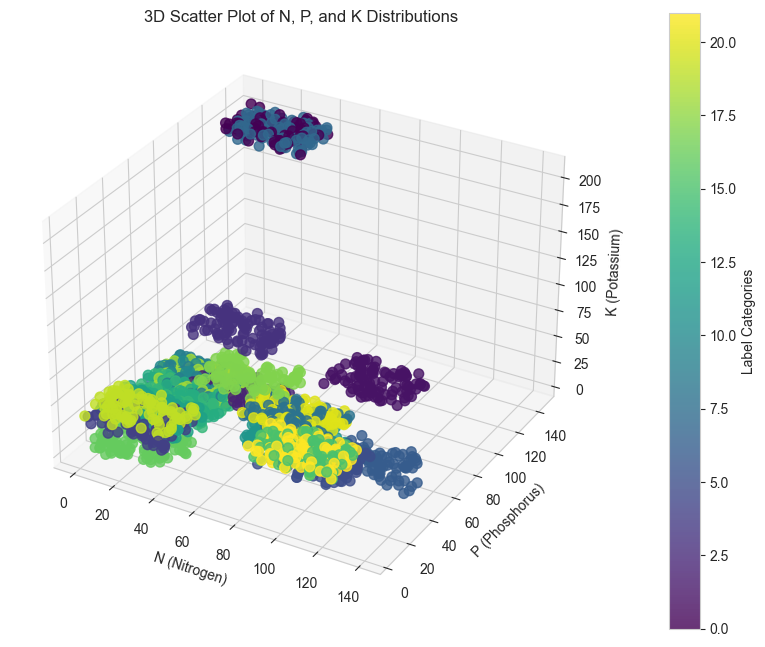

In [ ]:
# 3D scatter plot of N, P, K colored by crop type

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(
    df['N'], 
    df['P'], 
    df['K'], 
    c=df['label'].astype('category').cat.codes, # Converts text labels to numbers for coloring
    cmap='viridis',                             # Color palette
    s=50,                                       # Size of the data points
    alpha=0.8                                   # Transparency
)

ax.set_xlabel('N (Nitrogen)')
ax.set_ylabel('P (Phosphorus)')
ax.set_zlabel('K (Potassium)')
ax.set_title('3D Scatter Plot of N, P, and K Distributions')

# 5. Add a color bar legend
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Label Categories')

plt.show()

<h2>Modeling<h2>

In [ ]:
# split data into features and target variable
X = df.drop(columns=['label'])
y = df['label']


In [168]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
# define the model

param_grid = {
    'n_estimators': [50, 100, 200],     
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],        
    'min_samples_leaf': [1, 2]        
}

In [ ]:
rf = RandomForestClassifier(max_depth=2, random_state=0)

grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1, 
    verbose=1
)

# fit the model

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(max_depth=2, random_state=0),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
# evaluate the model

best_rfc = grid_search.best_estimator_
y_pred = best_rfc.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Evaluation ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

--- Model Evaluation ---
Overall Accuracy: 99.17%



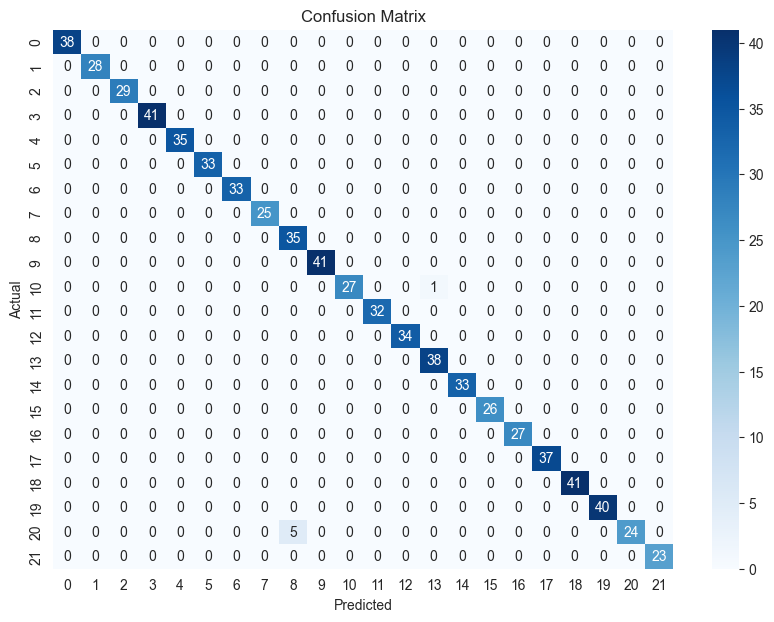

In [ ]:
# Classification report

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\raeve\AppData\Local\Temp\ipykernel_10064\2647323770.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


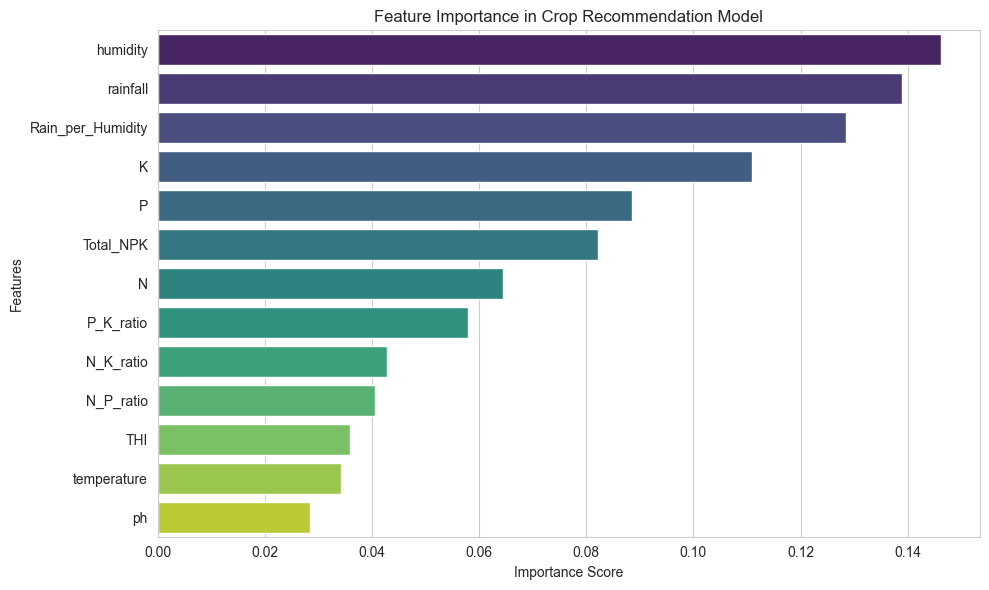

In [ ]:
# Feature importance

importances = pd.Series(best_rfc.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance in Crop Recommendation Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()